In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Load the dataset
df = pd.read_csv('18100205.csv')
# Display the first few rows of the dataset
print(df.head())
print(df.shape)


  REF_DATE              GEO           DGUID New housing price indexes  \
0  1981-01           Canada  2016A000011124    Total (house and land)   
1  1981-01           Canada  2016A000011124                House only   
2  1981-01           Canada  2016A000011124                 Land only   
3  1981-01  Atlantic Region      2016A00011    Total (house and land)   
4  1981-01  Atlantic Region      2016A00011                House only   

                 UOM  UOM_ID SCALAR_FACTOR  SCALAR_ID      VECTOR  COORDINATE  \
0  Index, 201612=100     347         units          0  v111955442         1.1   
1  Index, 201612=100     347         units          0  v111955443         1.2   
2  Index, 201612=100     347         units          0  v111955444         1.3   
3  Index, 201612=100     347         units          0  v111955445         2.1   
4  Index, 201612=100     347         units          0  v111955446         2.2   

   VALUE STATUS  SYMBOL  TERMINATED  DECIMALS  
0   38.2    NaN     NaN   

In [4]:
df['GEO'].unique()

array(['Canada', 'Atlantic Region', 'Newfoundland and Labrador',
       "St. John's, Newfoundland and Labrador", 'Prince Edward Island',
       'Charlottetown, Prince Edward Island', 'Nova Scotia',
       'Halifax, Nova Scotia', 'New Brunswick',
       'Saint John, Fredericton, and Moncton, New Brunswick', 'Quebec',
       'Québec, Quebec', 'Sherbrooke, Quebec', 'Trois-Rivières, Quebec',
       'Montréal, Quebec', 'Ottawa-Gatineau, Quebec part, Ontario/Quebec',
       'Ontario', 'Ottawa-Gatineau, Ontario part, Ontario/Quebec',
       'Oshawa, Ontario', 'Toronto, Ontario', 'Hamilton, Ontario',
       'St. Catharines-Niagara, Ontario',
       'Kitchener-Cambridge-Waterloo, Ontario', 'Guelph, Ontario',
       'London, Ontario', 'Windsor, Ontario', 'Greater Sudbury, Ontario',
       'Prairie Region', 'Manitoba', 'Winnipeg, Manitoba', 'Saskatchewan',
       'Regina, Saskatchewan', 'Saskatoon, Saskatchewan', 'Alberta',
       'Calgary, Alberta', 'Edmonton, Alberta', 'British Columbia',
     

In [5]:
df.isnull().sum()

REF_DATE                         0
GEO                              0
DGUID                         1632
New housing price indexes        0
UOM                              0
UOM_ID                           0
SCALAR_FACTOR                    0
SCALAR_ID                        0
VECTOR                           0
COORDINATE                       0
VALUE                        10826
STATUS                       36028
SYMBOL                       65280
TERMINATED                   65280
DECIMALS                         0
dtype: int64

In [6]:
print(df['REF_DATE'].min())
print(df['REF_DATE'].max())

1981-01
2026-04


In [14]:
df_filtered = df[df['GEO'].isin(["St. John's, Newfoundland and Labrador", "Toronto, Ontario", "Vancouver, British Columbia", "Calgary, Alberta", "Halifax, Nova Scotia"])]
print(df_filtered.shape)

df_filtered = df_filtered[df_filtered['New housing price indexes'] == 'Total (house and land)']
df_filtered = df_filtered[['REF_DATE', 'GEO', 'VALUE']]
print(df_filtered.shape)

(8160, 15)
(2720, 3)


In [17]:
df_filtered['REF_DATE'] = pd.to_datetime(df_filtered['REF_DATE'])
print(df_filtered.dtypes)

REF_DATE    datetime64[ns]
GEO                 object
VALUE              float64
dtype: object


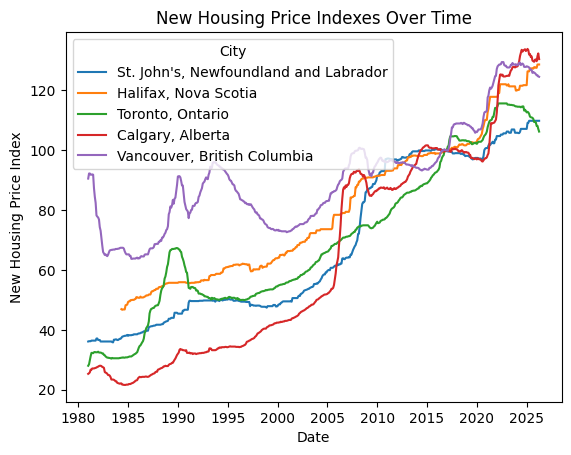

In [21]:
sns.lineplot(data=df_filtered, x='REF_DATE', y='VALUE', hue='GEO')
plt.title('New Housing Price Indexes Over Time')
plt.xlabel('Date')
plt.ylabel('New Housing Price Index')
plt.legend(title='City')
plt.show()

In [22]:
df_filtered['decade'] = df_filtered['REF_DATE'].dt.year // 10 * 10
print(df_filtered.head())

      REF_DATE                                    GEO  VALUE  decade
9   1981-01-01  St. John's, Newfoundland and Labrador   36.1    1980
21  1981-01-01                   Halifax, Nova Scotia    NaN    1980
57  1981-01-01                       Toronto, Ontario   28.0    1980
102 1981-01-01                       Calgary, Alberta   25.3    1980
114 1981-01-01            Vancouver, British Columbia   90.5    1980


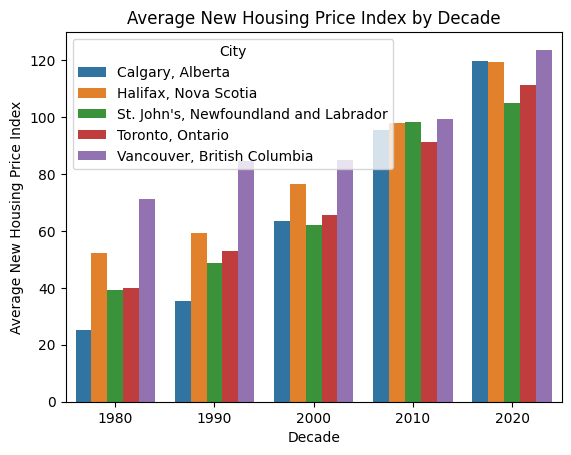

In [30]:
decade_avg = df_filtered.groupby(['decade', 'GEO'])['VALUE'].mean()
decade_avg = decade_avg.reset_index()
plt.title('Average New Housing Price Index by Decade')
plt.xlabel('Decade')
plt.ylabel('Average New Housing Price Index')
sns.barplot(data=decade_avg, x='decade', y='VALUE', hue='GEO').legend(title='City')

In [31]:
df_pandemic = df_filtered[df_filtered['REF_DATE'] >= '2020-01-01']
print(df_pandemic.shape)

(380, 4)


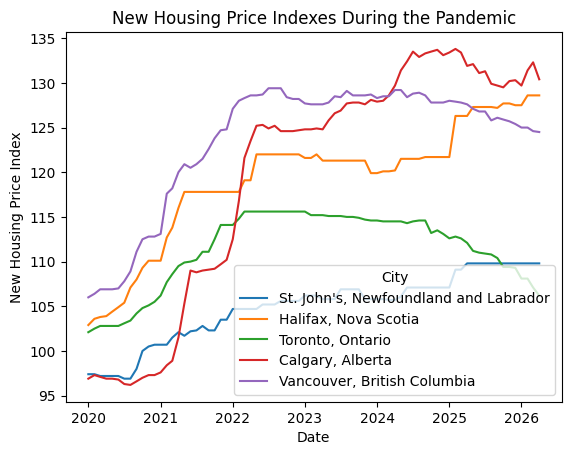

In [32]:
sns.lineplot(data=df_pandemic, x='REF_DATE', y='VALUE', hue='GEO')
plt.title('New Housing Price Indexes During the Pandemic')
plt.xlabel('Date')
plt.ylabel('New Housing Price Index')
plt.legend(title='City')

In [33]:
df_clean = df_filtered.dropna(subset=['VALUE'])
first_values = df_clean.groupby('GEO')['VALUE'].first()
last_values = df_clean.groupby('GEO')['VALUE'].last()
print(first_values)
print(last_values)

GEO
Calgary, Alberta                         25.3
Halifax, Nova Scotia                     46.9
St. John's, Newfoundland and Labrador    36.1
Toronto, Ontario                         28.0
Vancouver, British Columbia              90.5
Name: VALUE, dtype: float64
GEO
Calgary, Alberta                         130.4
Halifax, Nova Scotia                     128.6
St. John's, Newfoundland and Labrador    109.8
Toronto, Ontario                         106.2
Vancouver, British Columbia              124.5
Name: VALUE, dtype: float64


In [ ]:
growth_rate = (last_values - first_values) / first_values * 100
print(growth_rate)